#  Решение задачи регрессии при помощи пакета `torch`. Метрики.

__Автор задач: Блохин Н.В. (NVBlokhin@fa.ru)__

Материалы:
* Deep Learning with PyTorch (2020) Авторы: Eli Stevens, Luca Antiga, Thomas Viehmann
* https://pytorch.org/docs/stable/nn.html
* https://pytorch.org/docs/stable/optim.html
* https://github.com/Lightning-AI/torchmetrics
* https://pytorch.org/docs/stable/generated/torch.no_grad.html
* https://pytorch-lightning.readthedocs.io/en/2.1.2/pytorch/ecosystem/metrics.html#torchmetrics

## Задачи для совместного разбора

In [2]:
!pip install torchtyping
!pip install torchmetrics

  Attempting uninstall: typeguard
    Found existing installation: typeguard 4.5.1
    Uninstalling typeguard-4.5.1:
      Successfully uninstalled typeguard-4.5.1
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 9.8 MB/s eta 0:00:00


In [3]:
from torchtyping import TensorType, patch_typeguard
from typeguard import typechecked

Scalar = TensorType[()]
patch_typeguard()

In [4]:
import torch as th
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchmetrics import MeanSquaredError, R2Score, MeanAbsoluteError, MeanAbsolutePercentageError, MeanSquaredLogError
from sklearn.datasets import make_regression
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import time
import numpy as np

th.manual_seed(42)

1\. Используя реализацию из `torch.nn`, решите задачу регрессии. Для расчета градиентов воспользуйтесь возможностями по автоматическому дифференцированию `torch`. В качестве функции потерь используйте собственную реализацию MSE. Для настройки весов реализуйте пакетный градиентный спуск с использованием `torch.optim.SGD`.

In [5]:
from sklearn.datasets import make_regression

X, y, coef = make_regression(n_features=4, n_informative=4, coef=True, bias=0.5, random_state=42)
X = th.FloatTensor(X)
y = th.FloatTensor(y)

## Задачи для самостоятельного решения

<p class="task" id="1"></p>

1\. Используя реализацию полносвязного слоя из `torch.nn` решите задачу регрессии. В качестве функции потерь используйте реализацию MSE из `torch.nn`. Для настройки весов реализуйте мини-пакетный градиентный спуск с использованием `torch.optim.SGD`. Для создания модели опишите класс `SineModel`.

Предлагаемая архитектура нейронной сети:
1. Полносвязный слой с 100 нейронами
2. Активация ReLU
3. Полносвязный слой с 1 нейроном

В процессе обучения сохраняйте промежуточные прогнозы моделей. Визуализируйте облако точек и прогнозы модели в начале, середине и после окончания процесса обучения (не обязательно три, можно взять больше промежуточных вариантов).

Выведите график изменения значения функции потерь в процессе обучения. Логику расчета значения функции потерь на уровне эпохи реализуйте самостоятельно.

- [ ] Проверено на семинаре

In [19]:
X = th.linspace(0, 1, 100).view(-1, 1)
y = th.sin(2 * th.pi * X) + 0.1 * th.rand(X.size())

In [20]:
import torch.nn as nn
class SineModel(nn.Module):
    def __init__(self, n_features: int, n_hidden: int, n_out: int) -> None:
        super().__init__()
        self.fc1 = nn.Linear(1, 100)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(100, 1)

    def forward(self, X: TensorType["batch", "n_features"]) -> TensorType["batch", 1]:
        X = self.fc1(X)
        X = self.relu(X)
        X = self.fc2(X)
        return X

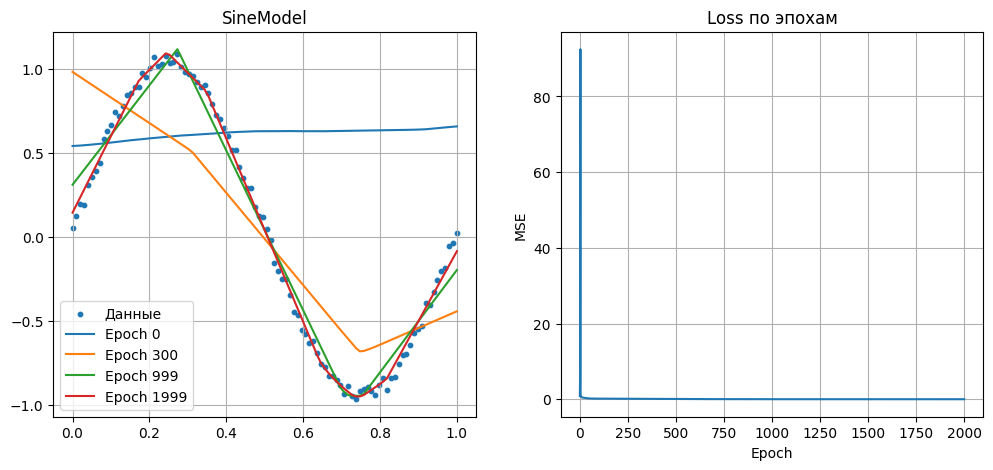

In [21]:
model = SineModel(1, 0, 1)
criterion = nn.MSELoss()
optimizer = optim.SGD(model.parameters(), lr=0.1)

preds_history = []
loss_history = []

epochs = 2000
for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model(X)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch in [0, 300, 999, 1999]:
        preds_history.append((epoch, y_pred.detach().clone()))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X.numpy(), y.numpy(), s=10, label='Данные')
for e, p in preds_history:
    plt.plot(X.numpy(), p.numpy(), label=f'Epoch {e}')
plt.legend()
plt.title('SineModel')
plt.grid()

plt.subplot(1, 2, 2)
plt.plot(loss_history)
plt.title('Loss по эпохам')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.grid()
plt.show()

<p class="task" id="2"></p>

2\. Повторите решение задачи 1, изменив модель. Для создания модели создайте объект класса `nn.Sequential`.

Предлагаемая архитектура нейронной сети:
1. Полносвязный слой с 50 нейронами
2. Активация Tanh
3. Полносвязный слой с 1 нейроном

- [ ] Проверено на семинаре

In [22]:
X = th.linspace(0, 1, 100).view(-1, 1)
y = th.sin(2 * th.pi * X) + 0.1 * th.rand(X.size())

In [23]:
model_seq = nn.Sequential(
    nn.Linear(1, 50),
    nn.Tanh(),
    nn.Linear(50, 1)
)

optimizer = optim.SGD(model_seq.parameters(), lr=0.1)
criterion = nn.MSELoss()

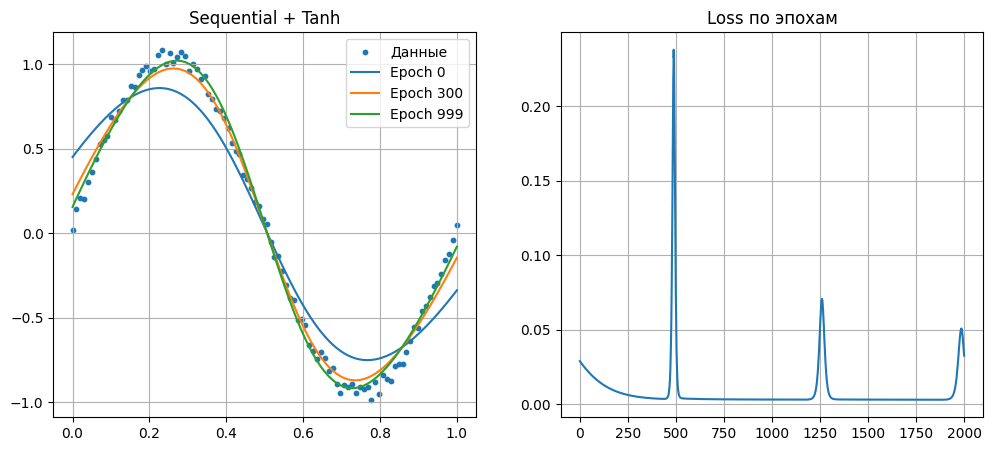

In [25]:
preds_history = []
loss_history = []

for epoch in range(epochs):
    optimizer.zero_grad()
    y_pred = model_seq(X)
    loss = criterion(y_pred, y)
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if epoch in [0, 300, 999]:
        preds_history.append((epoch, y_pred.detach().clone()))

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.scatter(X.numpy(), y.numpy(), s=10, label='Данные')
for e, p in preds_history:
    plt.plot(X.numpy(), p.numpy(), label=f'Epoch {e}')
plt.legend()
plt.grid()
plt.title('Sequential + Tanh')

plt.subplot(1, 2, 2)
plt.plot(loss_history)
plt.title('Loss по эпохам')
plt.grid()
plt.show()

<p class="task" id="3"></p>

3\. Используя реализацию полносвязного слоя из `torch.nn`, решите задачу регрессии. В качестве функции потерь используйте реализацию MSE из `torch.nn`. Для настройки весов реализуйте мини-пакетный градиентный спуск с использованием `torch.optim.SGD`. Перенесите вычисления на GPU и сравните время обучения с и без использования GPU. Решение должно корректно работать в случае отсутствия GPU без дополнительных изменений в коде.

- [ ] Проверено на семинаре

In [27]:
X, y, coef = make_regression(
    n_samples=10000,
    n_features=10,
    n_informative=6,
    coef=True,
    bias=0.5,
    random_state=42
)
X = th.FloatTensor(X)
y = th.FloatTensor(y).reshape(-1, 1)

In [15]:
model_gpu = nn.Sequential(
    nn.Linear(10, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

criterion = nn.MSELoss()
optimizer = optim.SGD(model_gpu.parameters(), lr=0.01)

device = 'cuda' if th.cuda.is_available() else 'cpu'
print(f'Используется устройство: {device}')

model_gpu.to(device)
X_dev = X.to(device)
y_dev = y.to(device)

loader = DataLoader(TensorDataset(X_dev, y_dev), batch_size=256, shuffle=True)

start = time.time()
epochs = 50
for epoch in range(epochs):
    for X, y in loader:
        optimizer.zero_grad()
        y_pred = model_gpu(X)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer.step()
print(f'Время обучения на {device}: {time.time()-start if device=="cuda" else cpu_time:.2f} сек')

Используется устройство: cuda
Время обучения на cuda: 0.07 сек


In [30]:
model_cpu = nn.Sequential(nn.Linear(10, 64), nn.ReLU(), nn.Linear(64, 1))
optimizer_cpu = optim.SGD(model_cpu.parameters(), lr=0.01)
X_cpu = X
y_cpu = y
loader_cpu = DataLoader(TensorDataset(X_cpu, y_cpu), batch_size=256, shuffle=True)

epochs = 50
start = time.time()
for epoch in range(epochs):
    for X, y in loader_cpu:
        optimizer_cpu.zero_grad()
        y_pred = model_cpu(X)
        loss = criterion(y_pred, y)
        loss.backward()
        optimizer_cpu.step()
cpu_time = time.time() - start
print(f'Время на CPU: {cpu_time:.2f} сек')

Время на CPU: 11.04 сек


<p class="task" id="4"></p>

4\. Повторите решение задач 1-2, используя для расчета значения функции потерь за эпоху метрику `MeanMetric` из пакета `torchmetrics`. Добавьте в цикл обучения расчет метрики $R^2$ (воспользуйтесь реализацией из `torchmetrics`). Выведите на экран график изменения значения функции потерь и метрики $R^2$ по эпохам в процессе обучения.

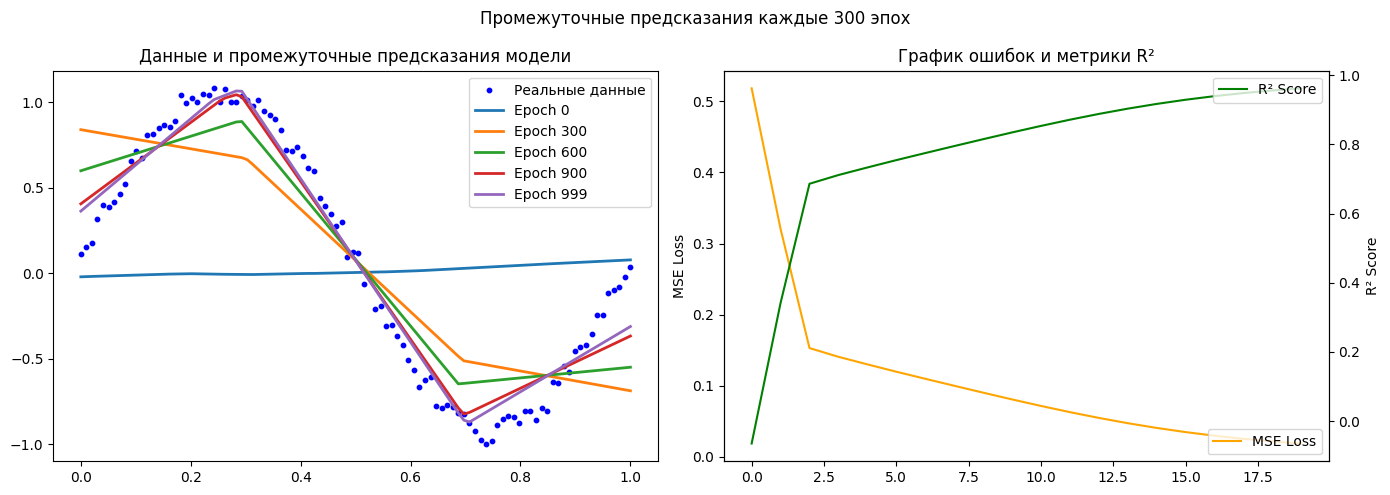

In [42]:
X4 = th.linspace(0, 1, 100).view(-1, 1)
y4 = th.sin(2 * th.pi * X4) + 0.15 * th.rand(X4.size())

model4 = nn.Sequential(
    nn.Linear(1, 100),
    nn.ReLU(),
    nn.Linear(100, 1)
)

optimizer = optim.SGD(model4.parameters(), lr=0.1)
criterion = nn.MSELoss()

r2_metric = R2Score()
mse_metric = MeanSquaredError()

loss_hist4 = []
r2_hist4 = []
preds_history4 = []

for epoch in range(1000):
    optimizer.zero_grad()
    pred = model4(X4)
    loss = criterion(pred, y4)
    loss.backward()
    optimizer.step()

    #Сохраняем промежуточные предсказания раз в 300 итераций + финальное
    if epoch % 300 == 0 or epoch == 999:
        preds_history4.append((epoch, pred.detach().clone()))

    #Метрики каждые 50 эпох
    if epoch % 50 == 0:
        mse_metric.update(pred, y4)
        r2_metric.update(pred, y4)
        loss_hist4.append(loss.item())
        r2_hist4.append(r2_metric.compute().item())
        mse_metric.reset()
        r2_metric.reset()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Левый график: данные + несколько предсказаний
axes[0].scatter(X4.numpy(), y4.numpy(), s=10, color='blue', label='Реальные данные')
for e, p in preds_history4:
    axes[0].plot(X4.numpy(), p.numpy(), linewidth=2, label=f'Epoch {e}')
axes[0].set_title('Данные и промежуточные предсказания модели')
axes[0].legend()

#Правый график: ошибки (Loss + R²)
axes[1].plot(loss_hist4, label='MSE Loss', color='orange')
axes[1].set_ylabel('MSE Loss')
ax2 = axes[1].twinx()
ax2.plot(r2_hist4, label='R² Score', color='green')
ax2.set_ylabel('R² Score')
axes[1].set_title('График ошибок и метрики R²')
axes[1].legend(loc='lower right')
ax2.legend(loc='upper right')

plt.suptitle('Промежуточные предсказания каждые 300 эпох')
plt.tight_layout()
plt.show()

<p class="task" id="5"></p>

5\. Повторите решение задач 1-2, изменив функцию потерь. Обучите модель, используя три функции потерь: `MSELoss`, `L1Loss` и `HuberLoss` - и выведите на одном графике динамику изменения метрики $R^2$ по эпохам для каждой модели в процессе обучения. Добавьте подписи полученных кривых.

- [ ] Проверено на семинаре

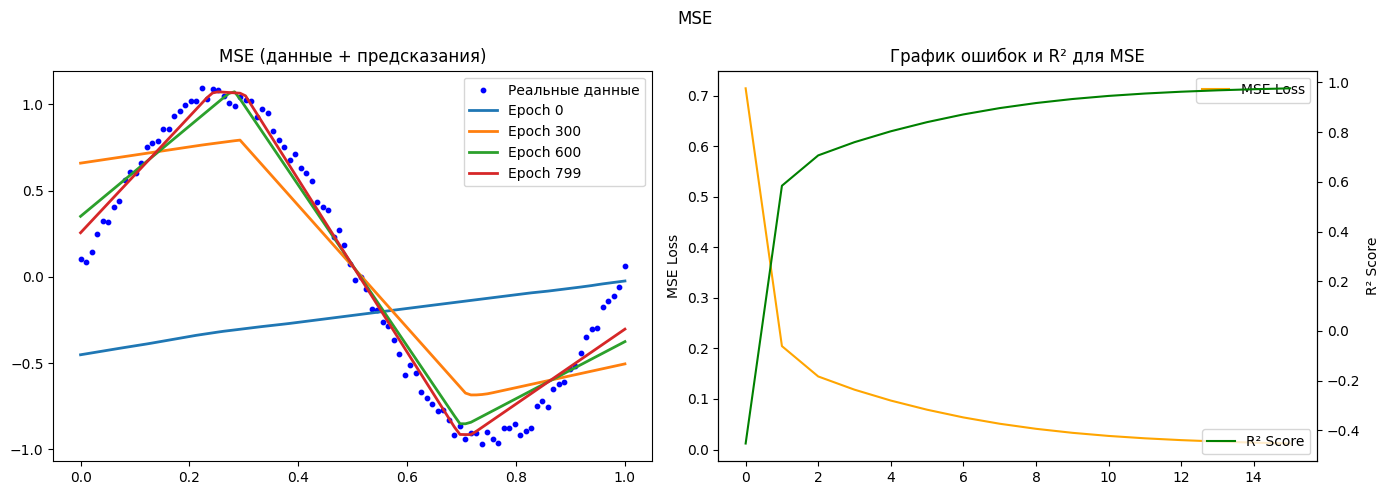

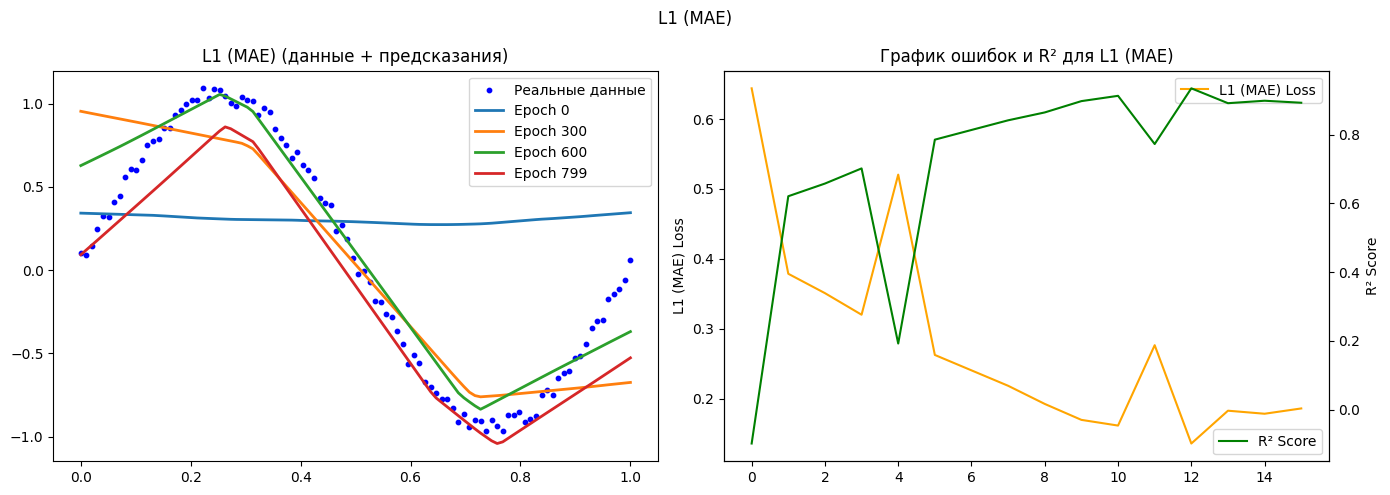

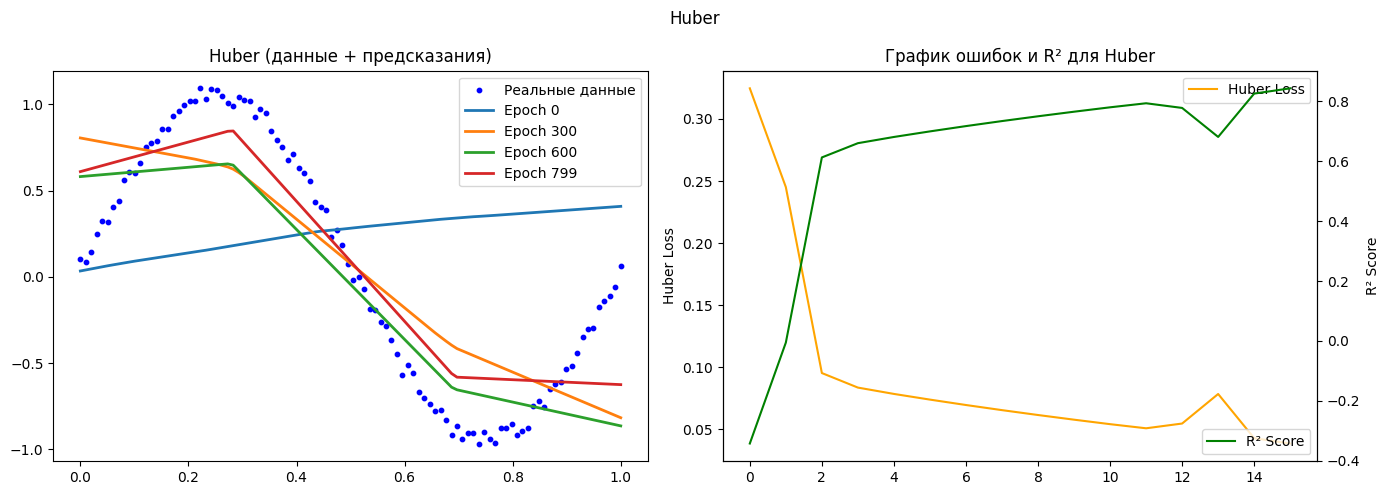

In [47]:
X5 = th.linspace(0, 1, 100).view(-1, 1)
y5 = th.sin(2 * th.pi * X5) + 0.12 * th.rand(X5.size())

losses = [nn.MSELoss(), nn.L1Loss(), nn.HuberLoss(delta=1.0)]
labels = ['MSE', 'L1 (MAE)', 'Huber']

for loss_fn, name in zip(losses, labels):
    model = nn.Sequential(nn.Linear(1, 100), nn.ReLU(), nn.Linear(100, 1))
    optimizer = optim.SGD(model.parameters(), lr=0.1)
    r2 = R2Score()

    loss_hist = []
    r2_hist = []
    preds_history = []

    for epoch in range(800):
        optimizer.zero_grad()
        pred = model(X5)
        loss = loss_fn(pred, y5)
        loss.backward()
        optimizer.step()

        if epoch % 300 == 0 or epoch == 799:
            preds_history.append((epoch, pred.detach().clone()))

        if epoch % 50 == 0:
            r2.update(pred, y5)
            r2_hist.append(r2.compute().item())
            loss_hist.append(loss.item())
            r2.reset()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    #Левый: данные + промежуточные предсказания
    axes[0].scatter(X5.numpy(), y5.numpy(), s=10, color='blue', label='Реальные данные')
    for e, p in preds_history:
        axes[0].plot(X5.numpy(), p.numpy(), linewidth=2, label=f'Epoch {e}')
    axes[0].set_title(f'{name} (данные + предсказания)')
    axes[0].legend()

    #Правый: Loss + R²
    axes[1].plot(loss_hist, label=f'{name} Loss', color='orange')
    axes[1].set_ylabel(f'{name} Loss')
    ax2 = axes[1].twinx()
    ax2.plot(r2_hist, label='R² Score', color='green')
    ax2.set_ylabel('R² Score')
    axes[1].set_title(f'График ошибок и R² для {name}')
    axes[1].legend(loc='upper right')
    ax2.legend(loc='lower right')

    plt.suptitle(f'{name}')
    plt.tight_layout()
    plt.show()

<p class="task" id="6"></p>

6\. Повторите решение задач 1-2, разделив датасет на обучающую и тестовую выборку в соотношении 80% на 20%. Обучите модель. Для тестовой выборки посчитайте и выведите на экран значения метрик:

- MAE;
- MAPE;
- MSE;
- MSLE (MeanSquaredLogError).


- [ ] Проверено на семинаре

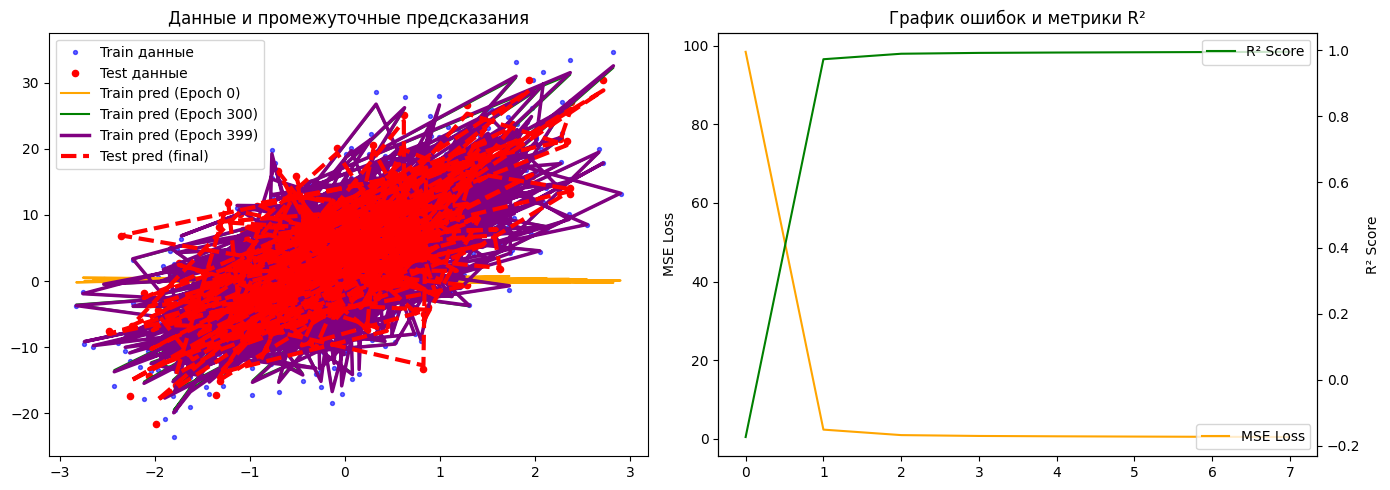

MAE  = 0.4749
MAPE = 0.1333
MSE  = 0.3895
MSLE = nan
R²   = 0.9953


In [60]:
n_samples = 1200
n_features = 5

X6 = th.randn(n_samples, n_features) * 3.0
true_coef = th.tensor([2.0, -1.5, 0.8, 1.2, -0.9]).view(-1, 1)
true_bias = 4.0

y6 = X6 @ true_coef + true_bias + th.randn(n_samples, 1) * 0.05

X_train, X_test, y_train, y_test = train_test_split(X6.numpy(), y6.numpy(), test_size=0.2, random_state=42)

X_train = th.FloatTensor(X_train)
X_test  = th.FloatTensor(X_test)
y_train = th.FloatTensor(y_train).view(-1, 1)
y_test  = th.FloatTensor(y_test).view(-1, 1)

# Нормализация X
X_mean = X_train.mean(dim=0)
X_std  = X_train.std(dim=0) + 1e-8
X_train = (X_train - X_mean) / X_std
X_test  = (X_test  - X_mean) / X_std

#Модель
model6 = nn.Sequential(
    nn.Linear(5, 64),
    nn.ReLU(),
    nn.Linear(64, 1)
)

optimizer = optim.SGD(model6.parameters(), lr=0.005)
criterion = nn.MSELoss()
r2_metric = R2Score()

loss_hist6 = []
r2_hist6 = []
preds_history6 = []

for epoch in range(400):
    optimizer.zero_grad()
    pred = model6(X_train)
    loss = criterion(pred, y_train)
    loss.backward()
    optimizer.step()

    if epoch % 300 == 0 or epoch == 399:
        preds_history6.append((epoch, pred.detach().clone()))

    if epoch % 50 == 0:
        r2_metric.update(pred, y_train)
        r2_hist6.append(r2_metric.compute().item())
        loss_hist6.append(loss.item())
        r2_metric.reset()

#Финальное предсказание на тесте
model6.eval()
with th.no_grad():
    pred_test = model6(X_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

#Левый график — используем 1-й признак
x_train_feat = X_train[:, 0].numpy()
x_test_feat  = X_test[:, 0].numpy()

axes[0].scatter(x_train_feat, y_train.numpy(), s=8, color='blue', alpha=0.6, label='Train данные')
axes[0].scatter(x_test_feat, y_test.numpy(), s=20, color='red', label='Test данные')

#Промежуточные предсказания — разные цвета и толщина
colors = ['orange', 'green', 'purple', 'brown', 'black']
for i, (e, p) in enumerate(preds_history6):
    axes[0].plot(x_train_feat, p.numpy(), linewidth=2.5 if i == len(preds_history6)-1 else 1.5,
                 color=colors[i % len(colors)], label=f'Train pred (Epoch {e})')

#Финальное предсказание на тесте — толстая красная линия
axes[0].plot(x_test_feat, pred_test.numpy(), '--', color='red', linewidth=3, label='Test pred (final)')

axes[0].set_title('Данные и промежуточные предсказания')
axes[0].legend()

#Правый график — Loss + R²
axes[1].plot(loss_hist6, label='MSE Loss', color='orange')
axes[1].set_ylabel('MSE Loss')
ax2 = axes[1].twinx()
ax2.plot(r2_hist6, label='R² Score', color='green')
ax2.set_ylabel('R² Score')
axes[1].set_title('График ошибок и метрики R²')
axes[1].legend(loc='lower right')
ax2.legend(loc='upper right')

plt.tight_layout()
plt.show()

mae  = MeanAbsoluteError()(pred_test, y_test)
mape = MeanAbsolutePercentageError()(pred_test, y_test)
mse  = MeanSquaredError()(pred_test, y_test)
msle = MeanSquaredLogError()(pred_test, y_test)
r2_test = R2Score()(pred_test, y_test).item()

print(f'MAE  = {mae:.4f}')
print(f'MAPE = {mape:.4f}')
print(f'MSE  = {mse:.4f}')
print(f'MSLE = {msle:.4f}')
print(f'R²   = {r2_test:.4f}')